<a href="https://colab.research.google.com/github/Chaki34/python-basics/blob/main/pygame%20drowing%20tutorial%20project%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [91]:
# Run this in a Google Colab cell
!pip install pygame -q

pygame 2.6.1 (SDL 2.28.4, Python 3.12.13)
Hello from the pygame community. https://www.pygame.org/contribute.html


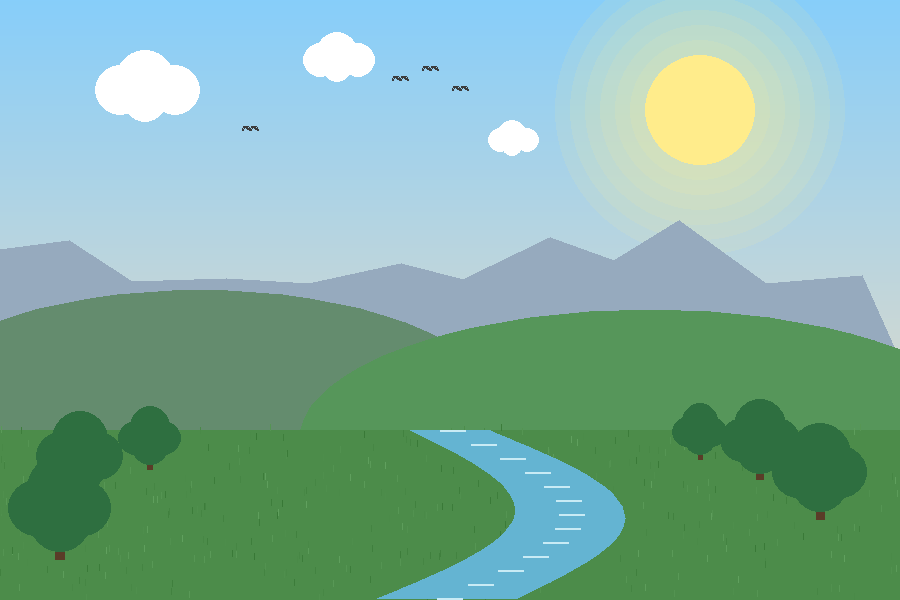

In [92]:
import os
os.environ["SDL_VIDEODRIVER"] = "dummy"  # headless mode for Colab

import pygame
import math
import random

pygame.init()

WIDTH, HEIGHT = 900, 600
screen = pygame.Surface((WIDTH, HEIGHT))

# ---------- Colors ----------
SKY_TOP = (135, 206, 250)
SKY_BOTTOM = (255, 223, 186)
SUN_COLOR = (255, 236, 139)
MOUNTAIN_FAR = (150, 170, 190)
MOUNTAIN_NEAR = (100, 140, 110)
HILL_COLOR = (86, 150, 90)
GRASS_COLOR = (76, 140, 74)
RIVER_COLOR = (100, 180, 210)
TREE_TRUNK = (90, 60, 40)
TREE_LEAF = (46, 111, 64)
CLOUD_COLOR = (255, 255, 255)

# ---------- Sky gradient ----------
for y in range(HEIGHT):
    t = y / HEIGHT
    r = int(SKY_TOP[0] * (1 - t) + SKY_BOTTOM[0] * t)
    g = int(SKY_TOP[1] * (1 - t) + SKY_BOTTOM[1] * t)
    b = int(SKY_TOP[2] * (1 - t) + SKY_BOTTOM[2] * t)
    pygame.draw.line(screen, (r, g, b), (0, y), (WIDTH, y))

# ---------- Sun with glow ----------
sun_x, sun_y, sun_r = 700, 110, 55
for i in range(6, 0, -1):
    alpha_surf = pygame.Surface((WIDTH, HEIGHT), pygame.SRCALPHA)
    pygame.draw.circle(alpha_surf, (*SUN_COLOR, 25), (sun_x, sun_y), sun_r + i * 15)
    screen.blit(alpha_surf, (0, 0))
pygame.draw.circle(screen, SUN_COLOR, (sun_x, sun_y), sun_r)

# ---------- Clouds ----------
def draw_cloud(x, y, scale=1.0):
    for dx, dy, r in [(0, 0, 25), (25, -10, 30), (55, 0, 25), (25, 10, 22)]:
        pygame.draw.circle(screen, CLOUD_COLOR,
                            (int(x + dx * scale), int(y + dy * scale)),
                            int(r * scale))

draw_cloud(120, 90, 1.0)
draw_cloud(320, 60, 0.7)
draw_cloud(500, 140, 0.5)

# ---------- Distant mountains ----------
def draw_mountain_range(base_y, color, roughness, peak_height):
    points = [(0, base_y)]
    x = 0
    while x <= WIDTH:
        points.append((x, base_y - random.randint(peak_height // 2, peak_height)))
        x += random.randint(60, 100)
    points.append((WIDTH, base_y))
    points.append((0, base_y))
    pygame.draw.polygon(screen, color, points)

random.seed(7)
draw_mountain_range(360, MOUNTAIN_FAR, 20, 140)

# ---------- Rolling hills ----------
def draw_hill(center_x, base_y, width, height, color):
    points = []
    for angle in range(180, 361, 5):
        rad = math.radians(angle)
        x = center_x + width * math.cos(rad)
        y = base_y + height * math.sin(rad)
        points.append((x, y))
    points.append((center_x + width, base_y))
    points.append((center_x - width, base_y))
    pygame.draw.polygon(screen, color, points)

draw_hill(200, 430, 320, 140, MOUNTAIN_NEAR)
draw_hill(650, 440, 350, 130, HILL_COLOR)

# ---------- Grass field ----------
pygame.draw.rect(screen, GRASS_COLOR, (0, 430, WIDTH, HEIGHT - 430))

# subtle grass texture
for _ in range(400):
    gx = random.randint(0, WIDTH)
    gy = random.randint(430, HEIGHT)
    shade = random.randint(-20, 20)
    c = tuple(max(0, min(255, ch + shade)) for ch in GRASS_COLOR)
    pygame.draw.line(screen, c, (gx, gy), (gx, gy - 6), 1)

# ---------- Winding river ----------
river_points_left = []
river_points_right = []
for y in range(430, HEIGHT, 4):
    t = (y - 430) / (HEIGHT - 430)
    center = 450 + 120 * math.sin(t * 3.2)
    width = 40 + 30 * t
    river_points_left.append((center - width, y))
    river_points_right.append((center + width, y))

river_poly = river_points_left + river_points_right[::-1]
pygame.draw.polygon(screen, RIVER_COLOR, river_poly)

# river shimmer
for y in range(430, HEIGHT, 14):
    t = (y - 430) / (HEIGHT - 430)
    center = 450 + 120 * math.sin(t * 3.2)
    pygame.draw.line(screen, (200, 235, 245),
                      (center - 10, y), (center + 15, y), 2)

# ---------- Trees ----------
def draw_tree(x, y, size=1.0):
    trunk_w = int(8 * size)
    trunk_h = int(35 * size)
    pygame.draw.rect(screen, TREE_TRUNK,
                      (x - trunk_w // 2, y - trunk_h, trunk_w, trunk_h))
    for dx, dy, r in [(0, -55, 26), (-18, -40, 22), (18, -40, 22), (0, -30, 24)]:
        pygame.draw.circle(screen, TREE_LEAF,
                            (int(x + dx * size), int(y + dy * size)),
                            int(r * size))

tree_spots = [(80, 500, 1.1), (150, 470, 0.8), (760, 480, 1.0),
              (820, 520, 1.2), (700, 460, 0.7), (60, 560, 1.3)]
for tx, ty, ts in tree_spots:
    draw_tree(tx, ty, ts)

# ---------- Birds ----------
def draw_bird(x, y, size=8):
    pygame.draw.arc(screen, (60, 60, 60), (x - size, y - size // 2, size, size), 0, math.pi, 2)
    pygame.draw.arc(screen, (60, 60, 60), (x, y - size // 2, size, size), 0, math.pi, 2)

for bx, by in [(400, 80), (430, 70), (460, 90), (250, 130)]:
    draw_bird(bx, by)

# ---------- Save & display in Colab ----------
pygame.image.save(screen, "nature_scene.png")

from IPython.display import Image, display
display(Image("nature_scene.png"))